In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)

block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
words_shuffled = words.copy()
random.shuffle(words_shuffled)

n1 = int(0.8 * len(words_shuffled))
n2 = int(0.9 * len(words_shuffled))

Xtr, Ytr = build_dataset(words_shuffled[:n1])
Xdev, Ydev = build_dataset(words_shuffled[n1:n2])
Xte, Yte = build_dataset(words_shuffled[n2:])

print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


In [2]:
n_embd = 10       # embedding size (instead of previous 2, a little bigger)
n_hidden = 200    # hidden layer size (instead of previous 100, a little bigger)

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

11897


In [3]:
ix = torch.randint(0, Xtr.shape[0], (32,))
Xb, Yb = Xtr[ix], Ytr[ix]

emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print(loss.item())

27.151357650756836


In [4]:
print(logits[0])

tensor([ -1.1061,  17.6027,   5.3113, -26.1630,  17.5420,   4.3182,  11.6709,
         19.5640,   6.9463,   3.8936,  15.7548, -12.3329,  -7.3124,   4.5098,
        -12.7937,  12.3270,  -3.2127,   1.4781,  15.1497, -14.6403,   5.1245,
         13.0823,   2.8490, -27.8297,   5.7948,  10.6830,  -5.5325],
       grad_fn=<SelectBackward0>)


In [5]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [6]:
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print(loss.item())

3.334054470062256


In [8]:
print(hpreact.abs())
print((hpreact.abs() > 0.99).float().mean())

tensor([[ 1.7367,  7.6010,  9.1858,  ...,  5.7191,  6.2432, 11.6469],
        [ 5.5885,  8.2634,  0.2595,  ...,  0.3059, 10.9300,  1.9276],
        [ 2.4382,  2.0602,  1.3323,  ...,  3.3112,  4.2392,  1.7576],
        ...,
        [ 2.2803,  4.8547,  6.4114,  ...,  1.0546,  0.8788,  0.3000],
        [ 3.1348,  8.5711,  1.4520,  ...,  6.2300,  7.4370,  7.3014],
        [ 6.0852,  4.9290,  8.2544,  ...,  8.8435,  4.3170,  4.4549]],
       grad_fn=<AbsBackward0>)
tensor(0.8561)


In [9]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [10]:
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print('loss:', loss.item())

print('saturation ratio:', (hpreact.abs() > 0.99).float().mean().item())

loss: 3.333082914352417
saturation ratio: 0.36421874165534973


In [12]:
fan_in = n_embd * block_size   # 30
W1_scale = 1 / (fan_in ** 0.5)
print(W1_scale)

0.18257418583505536


In [13]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)

fan_in = n_embd * block_size
W1_scale = (fan_in ** -0.5)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * W1_scale
b1 = torch.randn(n_hidden, generator=g) * 0.01

W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [14]:
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print('loss:', loss.item())
print('saturation ratio:', (hpreact.abs() > 0.99).float().mean().item())

loss: 3.3317551612854004
saturation ratio: 0.32374998927116394


In [15]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)

W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01

W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

12297


In [21]:
max_steps = 30000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1

    # batch normalization
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias

    h = torch.tanh(hpreact)
    h.retain_grad()
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 15000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 3000 == 0:
        print(f'iter {i}: loss={loss.item():.4f}')
    lossi.append(loss.log10().item())

iter 0: loss=2.3697
iter 3000: loss=2.3022
iter 6000: loss=2.1770
iter 9000: loss=2.1299
iter 12000: loss=2.3477
iter 15000: loss=1.9150
iter 18000: loss=2.4432
iter 21000: loss=2.7531
iter 24000: loss=2.1932
iter 27000: loss=1.6606


In [18]:
@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'dev': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1

    # batch norm - by using statistics of all training-set
    hpreact = bngain * (hpreact - hpreact_mean) / hpreact_std + bnbias

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

# firstly let's calculate the statistics for the entire training-set
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact_mean = hpreact.mean(0, keepdim=True)
    hpreact_std = hpreact.std(0, keepdim=True)

split_loss('train')
split_loss('dev')

train 2.158886671066284
dev 2.172434091567993


Text(0.5, 1.0, 'h (activation) distribution')

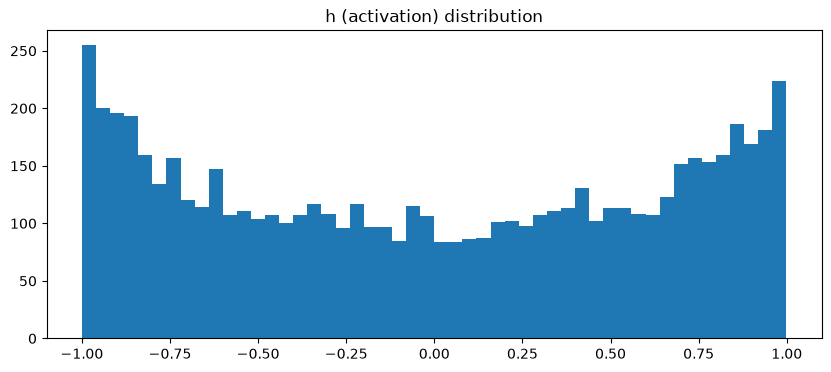

In [19]:
plt.figure(figsize=(10,4))
plt.hist(h.view(-1).tolist(), 50)
plt.title('h (activation) distribution')

Text(0.5, 1.0, 'h gradient distribution')

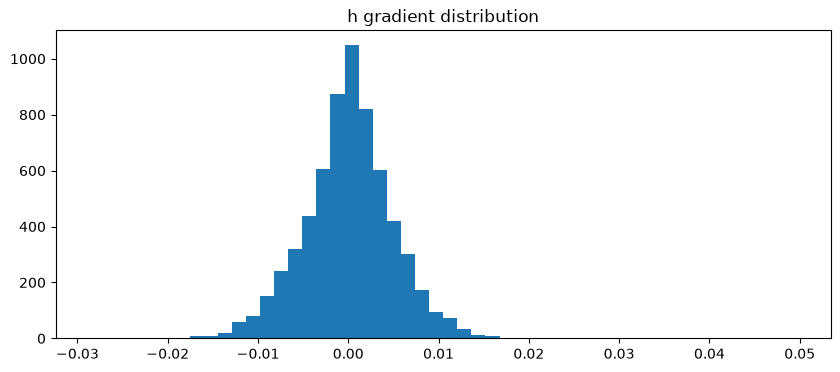

In [22]:
plt.figure(figsize=(10, 4))
plt.hist(h.grad.view(-1).tolist(), 50)
plt.title('h gradient distribution')